In [1]:
import sys
sys.path.append("/project01/ndcms/atownse2/ExponentialMixtureModel")

import ROOT
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tools import scale_out as so
import emm
import bias

Welcome to JupyROOT 6.30/04


In [2]:
# Load data
x = ROOT.RooRealVar("x", "Diphoton Mass [GeV]", 500, 10_000)
data_tree = emm.get_data(sort_and_index=True, tree=True)
data = ROOT.RooDataSet("mgg", "mgg", ROOT.RooArgSet(x), ROOT.RooFit.Import(data_tree))
n = data.numEntries()
data_mean = data.mean(x)
print(f"Data mean: {data_mean}")

Loaded 5036 diphoton invariant masses from data.
Data mean: 676.7652379849756


In [5]:
# Configuration
signal_points = [
    (600, 30),
    (700, 32.5),
    (800, 35),
    (900, 37.5),
    (1000, 40),
    (1100, 42.5),
    (1200, 45),
    (1300, 47.5),
    (1400, 50),
    (1500, 52.5),
    (1600, 55),
    (1700, 57.5),
    (1800, 60),
    (1900, 62.5),
    (2000, 65),
]

# Default
n_seeds = 20
n_toys_per_seed = 50

# Test
# n_seeds = 5
# n_toys_per_seed = 1

# Generate seeds
default_seed = 42
np.random.seed(default_seed)
seeds = np.random.randint(0, 10000, size=n_seeds)

In [6]:
# Set up models
toy_models = [
    emm.f1(x),
    emm.f2(x),
    emm.f3(x),
    emm.f4(x),
]

models = [
    emm.ExponentialMixtureModel_2,
    emm.ExponentialMixtureModel_3,
    # emm.ExponentialMixtureModel_4,
]
print(f"Will be submitting {n_seeds * len(toy_models)} tasks, with {n_toys_per_seed} toys fitting {len(models)} models and {len(signal_points)} signal points.")

# Fit toy models to data
for toy_model in toy_models:
    print(f"Fitting toy model: {toy_model.name}")
    toy_model.pdf.fitTo(data)

Will be submitting 80 tasks, with 50 toys fitting 2 models and 15 signal points.
Fitting toy model: f_1
Fitting toy model: f_2
Fitting toy model: f_3
Fitting toy model: f_4
[#1] INFO:NumericIntegration -- RooRealIntegral::init(f_1_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
Minuit2Minimizer: Minimize with max-calls 1000 convergence for edm < 1 strategy 1
Minuit2Minimizer : Valid minimum - status = 1
FVAL  = 31033.2097955985919
Edm   = 0.000159485240499530157
Nfcn  = 27
p1	  = 5.71808	 +/-  0.898473	(limited)
p2	  = -0.778647	 +/-  0.0667606	(limited)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:NumericIntegration -- RooRealIntegral::init(f_2_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimizati

Info in <Minuit2>: MnSeedGenerator Computing seed using NumericalGradient calculator
Info in <Minuit2>: MnSeedGenerator Initial state: FCN =       31033.41007 Edm =      0.4026341363 NCalls =      9
Info in <Minuit2>: MnSeedGenerator Initial state  
  Minimum value : 31033.41007
  Edm           : 0.4026341363
  Internal parameters:	[   -0.06003605845    -0.1202898824]	
  Internal gradient  :	[      -55.0368949     -36.51043855]	
  Internal covariance matrix:
[[  0.00026610788              0]
 [              0  0.00060350528]]]
Info in <Minuit2>: VariableMetricBuilder Start iterating until Edm is < 0.001 with call limit = 1000
Info in <Minuit2>: VariableMetricBuilder    0 - FCN =       31033.41007 Edm =      0.4026341363 NCalls =      9
Info in <Minuit2>: VariableMetricBuilder    1 - FCN =        31033.2098 Edm =   3.319820566e-06 NCalls =     15
Warning in <Minuit2>: MnPosDef Matrix forced pos-def by adding to diagonal 0.00459152
Info in <Minuit2>: VariableMetricBuilder After Hessian
I

In [6]:
# Run jobs
import os

tasks = []
for seed in seeds:
    for toy_model in toy_models:
        output = bias.signal_fits_filename(toy_model, seed, n_toys_per_seed)
        if os.path.exists(output):
            # print(f"Output {output} already exists, skipping.")
            continue
        _models = models
        _models.append(type(toy_model))
        tasks.append(so.Task(bias.fit_signal_models, x, toy_model, _models, seed, n_toys_per_seed, n, signal_points))

# print(len(tasks), "tasks to run.")
_ = so.run_tasks(
    tasks,
    use_condor=True,
    condor_job_name="spurious_signal",
    env_wrapper=so.run_in_mamba,
    clear_logs=True
)

Submitting 4 tasks to condor with job name 'spurious_signal'


In [7]:
# Load results
all_results = {}
for toy_model in toy_models:
    all_results[toy_model.name] = bias.load_signal_fit_results(toy_model, seeds, n_toys_per_seed)

In [8]:
# Organize results:
# Each signal point will have a distribution of fitted signal yields for each model
# signal_yields = {toy_model.name: {} for toy_model in toy_models}
all_results_df = []
for toy_model_name, toy_model_results in all_results.items():
    # One model will be the toy model and the others will be the exponential mixtures
    # toy_model_results = all_results[toy_model.name][toy_model.name]

    for seed_uid, signal_point_results in toy_model_results.items():
        for signal_point, fit_results in signal_point_results.items():

            if toy_model_name in fit_results:
                # Save true model
                result = {
                    "toy_model": toy_model_name,
                    "bkg_model": toy_model_name,
                    "seed_uid": seed_uid,
                    "signal_mean": signal_point[0],
                    "signal_width": signal_point[1],
                    "n_sig": fit_results[toy_model_name]["n_sig"],
                }
                all_results_df.append(result)

            # Find best exponential mixture
            best_exp_mixture_AIC = None
            best_AIC = np.inf
            best_exp_mixture_BIC = None
            best_BIC = np.inf
            # best_nll = np.inf
            for bkg_model_name, fit_result in fit_results.items():
                if "ExponentialMixture" not in bkg_model_name:
                    continue
                nll = fit_result["bkg_model_nll"]
                n_params = 2 * int(bkg_model_name.split("-")[-1])-1
                AIC = 2 * n_params + 2 * nll
                BIC = n_params * np.log(n) + 2 * nll
                if AIC < best_AIC:
                    best_AIC = AIC
                    best_exp_mixture_AIC = bkg_model_name
                if BIC < best_BIC:
                    best_BIC = BIC
                    best_exp_mixture_BIC = bkg_model_name
            
            result = {
                "toy_model": toy_model_name,
                "bkg_model": "ExponentialMixture (AIC)",
                "seed_uid": seed_uid,
                "signal_mean": signal_point[0],
                "signal_width": signal_point[1],
                "n_sig": fit_results[best_exp_mixture_AIC]["n_sig"],
            }
            all_results_df.append(result)

            result = {
                "toy_model": toy_model_name,
                "bkg_model": "ExponentialMixture (BIC)",
                "seed_uid": seed_uid,
                "signal_mean": signal_point[0],
                "signal_width": signal_point[1],
                "n_sig": fit_results[best_exp_mixture_BIC]["n_sig"],
            }
            all_results_df.append(result)

df = pd.DataFrame(all_results_df)

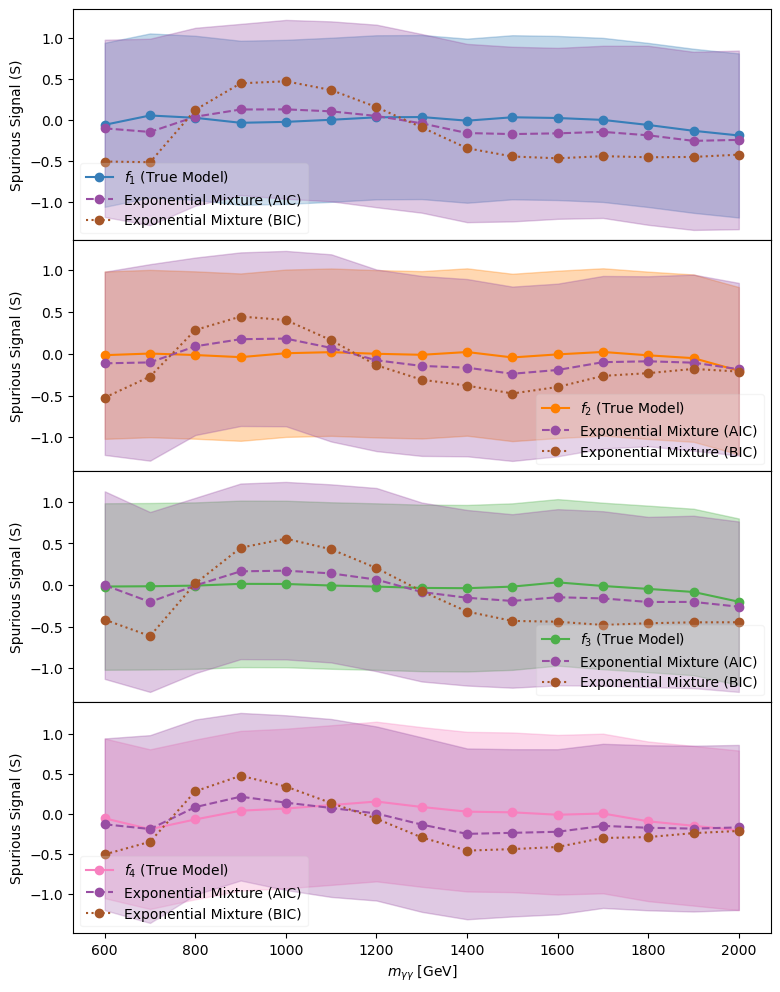

In [10]:
# Plot results
import matplotlib.pyplot as plt

toy_model_names = df["toy_model"].unique()

colors = {
    "f_1": '#377eb8',
    "f_2": '#ff7f00',
    "f_3": '#4daf4a',
    "f_4": '#f781bf',
    "ExponentialMixture (AIC)": '#984ea3',
    "ExponentialMixture (BIC)": '#a65628',
}
line_styles = ['solid', 'dashed', 'dotted']

fig, axs = plt.subplots(
    len(toy_model_names), 1,
    figsize=(9, 3 * len(toy_model_names)),
    sharex=True,
    gridspec_kw={"hspace": 0}
)
for i, toy_model_name in enumerate(toy_model_names):
    if len(toy_model_names) == 1:
        ax = axs
    else:
        ax = axs[i]
    # toy_model_name = toy_model.name
    toy_model_df = df[df["toy_model"] == toy_model_name]

    # Signal points
    models_to_plot = {
        toy_model_name: (toy_model_name, colors[toy_model_name], line_styles[0]),
        "ExponentialMixture (AIC)": ("Exponential Mixture (AIC)", colors["ExponentialMixture (AIC)"], line_styles[1]),
        "ExponentialMixture (BIC)": ("Exponential Mixture (BIC)", colors["ExponentialMixture (BIC)"], line_styles[2]),
    }

    y_err_true = None

    for bkg_model_name, (label, color, line_style) in models_to_plot.items():
        model_df = toy_model_df[toy_model_df["bkg_model"] == bkg_model_name]
        m = []
        y_raw = []
        y_err_raw = []
        for signal_mean in sorted(model_df["signal_mean"].unique()):
            signal_point_df = model_df[model_df["signal_mean"] == signal_mean]
            m.append(signal_mean)
            y_raw.append(signal_point_df["n_sig"].mean())
            y_err_raw.append(signal_point_df["n_sig"].std())

        if bkg_model_name == toy_model_name:
            y_err_true = np.array(y_err_raw)

        # Transform y and y_err to be in units of the error
        fun = lambda y_raw: np.array(y_raw)/y_err_true
        y = fun(y_raw)
        y_err_down = fun(np.array(y_raw) - np.array(y_err_raw))
        y_err_up = fun(np.array(y_raw) + np.array(y_err_raw))

        if "_" in label:
            label = f"${label}$"
        if bkg_model_name == toy_model_name:
            label = f"{label} (True Model)"

        ax.plot(m, y, label=label, marker="o", color=color, linestyle=line_style)
        if bkg_model_name == "ExponentialMixture (BIC)":
            continue
        ax.fill_between(m, y_err_down, y_err_up, alpha=0.3, color=color)

    ax.legend(framealpha=0.2)
    ax.set_xlabel("$m_{\gamma\gamma}$ [GeV]")
    # ax.set_ylabel("Spurious Signal Yield")
    ax.set_ylabel("Spurious Signal (S)")
    
